# CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026

## Project Checkpoint 2: Research Question Formation

**Dataset Details**

**US Airline Flight Routes and Fares (1993–2024)**

Summary:
US Airline Network and Fare Dataset consisting of airport nodes, route edges, and associated fare, distance, and market share information.

Source:
Kaggle – US Airline Flight Routes and Fares
https://www.kaggle.com/datasets/bhavikjikadara/us-airline-flight-routes-and-fares-1993-2024

Course Topic Alignment:

- Graph Mining: Airports as nodes, Routes as edges, Centrality measures, Community detection
- Clustering: Grouping routes by fare patterns
- Anomaly Detection: Detecting unusually high-priced routes

Potential Beyond-Course Techniques:

- Node embeddings (Node2Vec / DeepWalk)
- Graph Neural Networks (GNNs)
- Temporal network analysis
- Dynamic pricing modeling
- Causal inference on route competition

Dataset Size and Structure:

- Covers 1993–2024
- Millions of route-fare observations
- Tabular format
- Each row represents a route-year-quarter combination (depending on dataset granularity)
- This dataset has : Network structure (routes), Temporal dimension (years), Economic variable (fares)

This makes it rich for multi-dimensional analysis.

Data Types:
Origin airport (categorical), Destination airport (categorical), Year / Quarter, Fare price (numeric), Passenger counts, Market share, Distance

Target Variable(s):
- No single mandatory target
- Possible supervised targets: Fare prediction (regression), High-price vs low-price classification
- Strong support for unsupervised graph analysis-

Licensing / Usage Constraints:
- Public Kaggle dataset
- Educational/research use permitted
- Must follow Kaggle dataset license terms

**Key EDA Findings**

From Checkpoint 1 and the additional EDA in this notebook, I observed:

- The airline network is sparse but highly centralized, with a small number of hub airports having disproportionately high connectivity, making graph mining appropriate.
- Fare variability is high even for routes with similar distances, indicating that distance alone is insufficient to explain pricing behavior.
- Certain routes exhibit high market concentration, suggesting that competition may influence fares.
- Average fare by quarter is fairly similar, suggesting that seasonality may exist but is not dominant at the aggregate level.
- The degree distribution is highly skewed (long-tail), motivating the use of network-based analysis and representation learning techniques.
- Some columns have substantial missingness, but the core variables needed for this checkpoint (fare, nsmiles, airportid_1, airportid_2, quarter, passengers) are available and usable.

These findings motivate research questions that go beyond simple descriptive statistics and instead use network structure, clustering, and representation learning.

**Setup and Additional EDA**

**NOTE: For detailed EDA, explanation and observations, please refer to my Project Checkpoint 1 file : https://colab.research.google.com/drive/1ORW2AX0AzWLGc3NS8EubMy_oYfj4bglx?usp=drive_link**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import networkx as nx

**Load and clean data**

In [2]:
# Load data
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/Sem4/Data Mining/project/airline_data.csv"
df = pd.read_csv(file_path, low_memory=False)

# Keep a working copy
air = df.copy()

# Basic cleaning for columns needed in this checkpoint
required_cols = ['fare', 'nsmiles', 'quarter', 'airportid_1', 'airportid_2', 'passengers']
air = air.dropna(subset=required_cols).copy()

# Ensure numeric types where needed
numeric_cols = ['fare', 'nsmiles', 'quarter', 'airportid_1', 'airportid_2', 'passengers']
for col in numeric_cols:
    air[col] = pd.to_numeric(air[col], errors='coerce')

air = air.dropna(subset=numeric_cols).copy()

print("Shape after core cleaning:", air.shape)
air.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape after core cleaning: (245955, 23)


,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


**Additional EDA code**

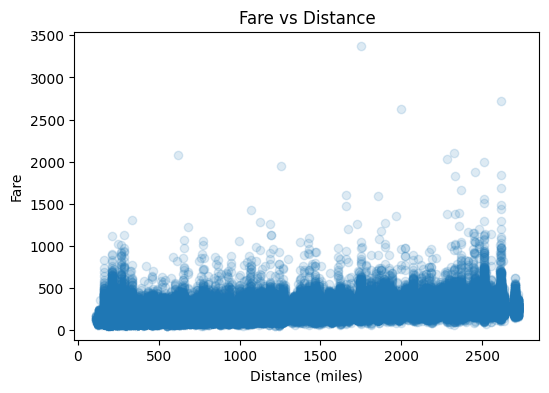

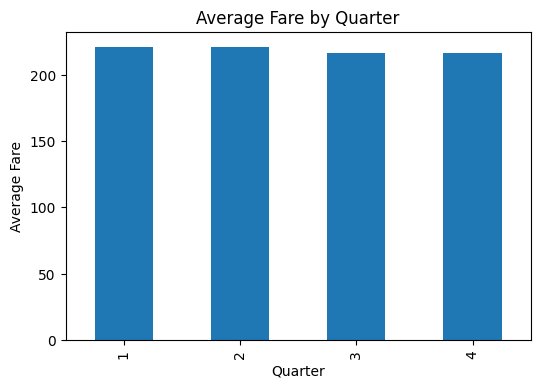

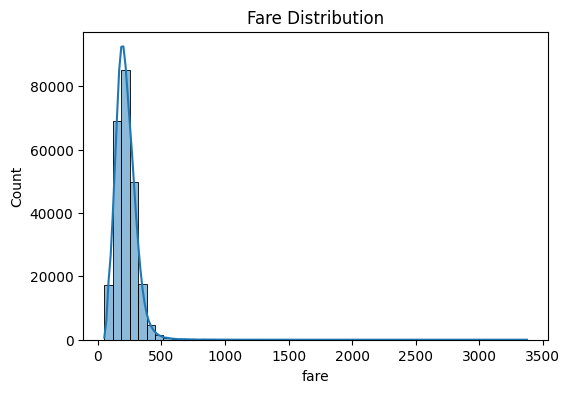

Geocoded_City2    39206
Geocoded_City1    39206
fare_low           1612
lf_ms              1612
carrier_low        1612
fare_lg            1540
large_ms           1540
carrier_lg         1540
tbl                   0
passengers            0
dtype: int64


In [3]:
import seaborn as sns
# 1. Fare vs Distance
plt.figure(figsize=(6, 4))
plt.scatter(air['nsmiles'], air['fare'], alpha=0.15)
plt.title("Fare vs Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare")
plt.show()

# 2. Average Fare by Quarter
plt.figure(figsize=(6, 4))
air.groupby('quarter')['fare'].mean().plot(kind='bar')
plt.title("Average Fare by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Fare")
plt.show()

# 3. Fare Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['fare'], bins=50, kde=True)
plt.title("Fare Distribution")
plt.show()

# 4. Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary.head(10))

### Additional EDA Interpretation

**1. Fare vs Distance**
The scatter plot shows a weak positive relationship between route distance and fare. In general, fares tend to rise somewhat as distance increases, but the spread is very large. Even among routes with similar mileage, the fares vary substantially. This means distance alone is not enough to explain pricing, which supports asking research questions about structural and market-based factors.

**2. Average Fare by Quarter**
The average fare by quarter is fairly stable across the four quarters. This suggests that seasonality does not dominate fare at the aggregate dataset level. However, this does not rule out route-specific or airport-specific seasonal effects. Because of that, quarter is still worth retaining as a feature in later analysis, but it should not be treated as the main explanatory variable.

**3. Fare Distribution**
The fare histogram is strongly right-skewed. Most routes have fares concentrated in a lower-to-middle range, while a smaller number of observations form a long tail of high fares. This is important because skewness and outliers can affect clustering and similarity-based methods. For that reason, scaling is necessary before clustering, and interpretation should account for extreme fare values.

**4. Missing Values**
The largest missing-value counts occur in geocoded location columns and carrier-specific fare-related columns. The core variables needed for this checkpoint—such as fare, route distance, quarter, passenger volume, and airport IDs—are available in usable quantity. Therefore, it is feasible to proceed without imputing high-missingness non-core columns.

**Why this matters for the project**
These EDA results support three main conclusions:
- Pricing depends on more than route distance.
- The data contains meaningful heterogeneity that may be captured by clustering.
- Because airports form a network, graph structure is a plausible source of explanatory signal.

These observations directly motivate the research questions below.

## Research Questions

## Research Question 1

### Research Question
**RQ1: How does the structural importance of airports in the airline network influence fare patterns, and does network structure provide useful signal beyond traditional factors such as route distance and quarter?**

### Data Mining Task Type
- **Graph mining / network analysis**

### Relevant Algorithm(s)
- **Degree centrality** (course technique)
- **Betweenness centrality** (course technique)

### Evaluation Criteria
- Correlation between airport centrality and fare-related statistics
- Interpretability of results
- Comparison against simpler baseline variables such as:
  - route distance (nsmiles)
  - quarter (quarter)

### Motivation and Feasibility
- **Motivation:** The EDA showed that fare varies widely even among routes with similar distances. That suggests route pricing may depend in part on airport role within the broader network.
- **Non-triviality:** A simple fare-vs-distance analysis ignores the fact that airports sit inside a connected transportation network. Centrality measures provide a way to quantify airport importance.
- **Feasibility:** The graph is easy to construct using 'airportid_1' and 'airportid_2'. Centrality measures are well-supported in NetworkX and feasible on this graph size.
- **Risks:** Sparse nodes may have unstable centrality values. Also, centrality is not the only factor affecting fare, so results should be interpreted as association rather than causation.

### Methodological Planning
- Build an undirected graph with airports as nodes and routes as edges.
- Compute degree centrality and betweenness centrality.
- Aggregate fares to the airport level using average outgoing fare.
- Compare airport-level fare statistics with centrality measures.
- Use distance-based analysis as a baseline reference.

### Why this algorithm choice makes sense
I chose degree and betweenness centrality because they are classic, interpretable graph mining measures:
- degree centrality captures how connected an airport is,
- betweenness centrality captures how much an airport lies on important connecting paths.

These are appropriate first structural features before moving to more complex external methods.

### Feasibility code for RQ1

In [4]:
# Build graph from airport pairs
G = nx.from_pandas_edgelist(
    air,
    source='airportid_1',
    target='airportid_2',
    create_using=nx.Graph()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Centrality measures
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, k=min(200, G.number_of_nodes()), seed=42)

# Airport-level average outgoing fare
airport_fare = (
    air.groupby('airportid_1')['fare']
    .mean()
    .rename('avg_outgoing_fare')
    .reset_index()
)

airport_fare['degree_centrality'] = airport_fare['airportid_1'].map(degree_cent)
airport_fare['betweenness_centrality'] = airport_fare['airportid_1'].map(betweenness_cent)

airport_fare[['avg_outgoing_fare', 'degree_centrality', 'betweenness_centrality']].corr()

Number of nodes: 221
Number of edges: 4102


,avg_outgoing_fare,degree_centrality,betweenness_centrality
avg_outgoing_fare,1.000000,0.098582,-0.011430
degree_centrality,0.098582,1.000000,0.807598
betweenness_centrality,-0.011430,0.807598,1.000000


### Initial Feasibility Result for RQ1
The graph was successfully constructed from the route data, and both degree and betweenness centrality were computed. This confirms that the graph-mining portion of the project is feasible. The resulting airport-level table now allows direct comparison between structural importance and average outgoing fare, which is sufficient to pursue this question in later stages.

Assumption note: For the checkpoint feasibility analysis, I model the airline network as an unweighted graph where airports are nodes and a route between two airports creates an edge. This intentionally simplifies repeated route observations across time and focuses on structural connectivity rather than route frequency.

## Research Question 2

### Research Question
**RQ2: Can clustering reveal distinct groups of airline routes with similar pricing behavior, and how do those groups differ in terms of distance, passenger volume, market share, and quarter?**

### Data Mining Task Type
- **Clustering**

### Relevant Algorithm(s)
- **K-Means** (course technique)

### Evaluation Criteria
- Silhouette score
- Cluster-wise summary statistics
- Interpretability of clusters in terms of fare, distance, passengers, and market share

### Motivation and Feasibility
- **Motivation:** The fare distribution is highly skewed and the scatter plot suggests wide variability even for similar route lengths. This indicates the dataset may contain distinct route types rather than one uniform population.
- **Non-triviality:** Looking only at fare averages or quartiles does not identify latent route segments. Clustering can discover hidden structure across multiple features simultaneously.
- **Feasibility:** The dataset is large but still manageable with scaled numeric features. K-Means is efficient, interpretable, and easy to validate with silhouette score.
- **Risks:** K-Means is sensitive to scaling and to the choice of 'k'. It also assumes roughly spherical clusters, which may not fully match real-world route behavior.

### Methodological Planning
- Use a route-level feature set including:
  - fare
  - distance (nsmiles)
  - passengers
  - market share variables (large_ms, lf_ms) when available
  - quarter
- Standardize features before clustering.
- Try a small range of 'k' values.
- Choose a reasonable 'k' using silhouette score and interpretability.
- Summarize clusters using feature means and sizes.

### Why this algorithm choice makes sense
I chose K-Means because it is a standard course clustering method, computationally feasible for this dataset, and appropriate for an initial segmentation of routes. It also makes later comparisons against more advanced or structure-aware methods easier.

### Feasibility code for RQ2

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Feature selection for clustering
cluster_cols = ['fare', 'nsmiles', 'passengers', 'quarter', 'large_ms', 'lf_ms']
cluster_df = air[cluster_cols].dropna().copy()

# Take a random sample for feasibility testing
cluster_sample = cluster_df.sample(n=min(10000, len(cluster_df)), random_state=42)

# Scale features
scaler = StandardScaler()
X_sample = scaler.fit_transform(cluster_sample)

# Try a small set of k values just for feasibility
scores = {}
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    scores[k] = silhouette_score(X_sample, labels)

scores

{2: 0.2398600336519561, 3: 0.23043208712080004}

In [6]:
# Choose best k
best_k = max(scores, key=scores.get)
print("Best k by silhouette:", best_k)

# Fit ONLY on sample
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_sample['cluster'] = kmeans.fit_predict(X_sample)

# Summary
cluster_summary = cluster_sample.groupby('cluster').agg(['mean', 'median', 'count'])
cluster_summary

Best k by silhouette: 2


fare                     nsmiles                passengers  \
               mean   median count         mean  median count        mean   
cluster                                                                     
0        232.416129  222.385  7006  1340.420639  1187.0  7006  336.917785   
1        185.676022  177.870  2994   838.220775   684.0  2994  208.774883   

                       quarter               large_ms                  lf_ms  \
        median count      mean median count      mean median count      mean   
cluster                                                                        
0        123.0  7006  2.464602    2.0  7006  0.570484   0.55  7006  0.263456   
1         82.0  2994  2.468270    2.0  2994  0.894594   0.95  2994  0.893516   

                      
        median count  
cluster               
0         0.22  7006  
1         0.95  2994

### Initial Feasibility Result for RQ2
K-Means runs successfully on the selected route-level features after scaling, and the silhouette score provides a principled way to choose the number of clusters. This confirms that the clustering question is feasible. The cluster summaries can be used to interpret whether different route segments exist, such as lower-fare short-haul routes versus higher-fare longer or lower-volume routes.

Note: For feasibility, clustering here is performed on a sampled subset of the dataset. This ensures faster execution while still validating that K-Means produces meaningful clusters. Full-scale clustering will be performed in later stages after parameter tuning.

## Research Question 3

### Research Question
**RQ3: Can Node2Vec embeddings capture latent airport similarities that are not visible through traditional centrality measures, and do those learned representations align with fare patterns better than simple graph statistics?**

### Data Mining Task Type
- **Graph representation learning**

### Relevant Algorithm(s)
- **Node2Vec** (external technique)

### Evaluation Criteria
- Whether embeddings can be successfully learned for airports in the graph
- Similarity structure in embedding space
- Comparison between embedding-derived clusters and centrality-based explanations
- Interpretability with respect to average outgoing fare

### Motivation and Feasibility
- **Motivation:** Centrality measures are useful but limited. They summarize airports using only a few handcrafted metrics. In contrast, Node2Vec can learn richer representations from local and higher-order graph structure.
- **Non-triviality:** Traditional centrality may miss airports that play similar structural roles even if their degree or betweenness is different. Node2Vec can potentially capture these latent similarities.
- **Feasibility:** Python implementations of Node2Vec exist, and the airport graph is of a size that should be manageable. A small-scale trial is enough at this checkpoint to verify that embeddings can be learned.
- **Risks:** Node2Vec introduces parameter sensitivity (walk length, number of walks, dimensions, return/in-out bias). It is also less interpretable than centrality measures.

### Methodological Planning
- Learn node embeddings for airports from the graph.
- Merge embeddings with airport-level average outgoing fare.
- Use either clustering or nearest-neighbor similarity in embedding space to inspect whether structurally similar airports show similar fare behavior.
- Compare these patterns against centrality-only features.

### Why this algorithm choice makes sense
I chose Node2Vec because it is a well-known external graph mining technique that extends beyond the course material while still being directly relevant to this network dataset. It is a natural next step after centrality-based analysis and allows a meaningful course-vs-external comparison.

In [7]:
!pip install node2vec

from node2vec import Node2Vec

# Small feasibility run
node2vec = Node2Vec(
    G,
    dimensions=16,
    walk_length=10,
    num_walks=20,
    workers=2,
    seed=42
)

n2v_model = node2vec.fit(window=5, min_count=1, batch_words=32)

# Convert embeddings into a dataframe
nodes = list(G.nodes())
embeddings = pd.DataFrame(
    [n2v_model.wv[str(node)] for node in nodes],
    index=nodes
)
embeddings.index.name = 'airportid_1'
embeddings.reset_index(inplace=True)

embeddings.head()

Computing transition probabilities:   0%|          | 0/221 [00:00<?, ?it/s]

,airportid_1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,10135,-0.180174,-0.303269,0.272111,0.139017,0.162858,0.311822,0.721735,0.341139,0.057069,0.130748,-0.053490,-0.475325,0.102058,-0.306097,-0.093742,0.188566
1,14112,-0.135694,-0.375008,0.449380,0.263038,0.232526,-0.053280,0.877373,0.119842,0.145336,0.054112,-0.018829,-0.402413,-0.137116,-0.415524,-0.024366,0.142310
2,15304,-0.104139,-0.337922,0.285971,0.278585,0.375928,0.040737,0.844299,0.249388,0.111058,0.079851,0.026768,-0.478067,-0.095937,-0.212338,-0.097861,0.071931
3,10140,-0.215023,-0.328766,0.199797,0.289132,0.192741,0.257764,0.671595,0.256585,0.089834,0.179139,0.019896,-0.566258,0.095386,-0.281057,-0.221345,0.069781
4,11259,-0.338298,-0.246684,0.270851,0.285993,0.367388,0.325228,0.724658,0.145536,0.068150,0.108493,0.006739,-0.428688,0.088355,-0.287146,-0.271624,0.019670


In [8]:
# Merge embeddings with airport-level fare
airport_embed = airport_fare.merge(embeddings, on='airportid_1', how='inner')
airport_embed.head()

,airportid_1,avg_outgoing_fare,degree_centrality,betweenness_centrality,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,10135,223.159242,0.027273,0.000007,-0.180174,-0.303269,0.272111,0.139017,0.162858,0.311822,0.721735,0.341139,0.057069,0.130748,-0.053490,-0.475325,0.102058,-0.306097,-0.093742,0.188566
1,10140,209.234983,0.186364,0.000069,-0.215023,-0.328766,0.199797,0.289132,0.192741,0.257764,0.671595,0.256585,0.089834,0.179139,0.019896,-0.566258,0.095386,-0.281057,-0.221345,0.069781
2,10154,212.120918,0.040909,0.000023,-0.333636,-0.210594,0.202806,0.278933,0.315491,0.455308,0.748787,0.269587,0.150766,0.148840,0.033009,-0.427881,0.281199,0.022969,-0.177454,0.095759
3,10157,141.187500,0.018182,0.000002,-0.245668,-0.263331,0.180962,0.165830,0.215563,0.196160,0.735515,0.264616,0.206825,0.099045,0.001662,-0.567548,0.151785,-0.249857,-0.156091,0.217388
4,10158,129.874027,0.050000,0.000010,-0.217205,-0.211524,0.327469,0.296074,0.184603,0.108868,0.759995,0.286181,0.061774,0.182405,-0.031885,-0.523595,-0.052652,-0.323197,-0.028663,0.076974


### Initial Feasibility Result for RQ3
The Node2Vec embedding model runs successfully on the airport graph and produces vector representations for airports. This confirms that the external method is feasible for the project. These embeddings can now be compared to centrality-based features in later analysis to see whether they capture fare-related similarity more effectively.

## RQ-to-Method Mapping Table

| RQ  | Research Question Focus | Data Mining Task Type | Algorithm(s) | Course / External | Evaluation Criteria |
|-----|--------------------------|-----------------------|--------------|-------------------|--------------------|
| RQ1 | Airport structural importance vs fare | Graph mining | Degree centrality, Betweenness centrality | Course | Correlation, interpretability, comparison vs distance/quarter |
| RQ2 | Hidden route segments | Clustering | K-Means | Course | Silhouette score, cluster summaries, interpretability |
| RQ3 | Latent airport similarity | Graph representation learning | Node2Vec | External | Embedding feasibility, similarity structure, comparison vs centrality |

## Method and Metric Plan

### RQ1: Graph Mining
- **Primary features:** airport centrality metrics
- **Target for interpretation:** average outgoing fare
- **Metrics / outputs:**
  - correlation matrix
  - ranked airports by centrality
  - comparison against baseline factors such as distance and quarter

### RQ2: Clustering
- **Primary features:** fare, nsmiles, passengers, quarter, large_ms, lf_ms
- **Preprocessing:** drop rows with missing clustering features, standardize numeric values
- **Metrics / outputs:**
  - silhouette score
  - cluster sizes
  - cluster-wise means and medians

### RQ3: Node2Vec
- **Primary object:** airport graph
- **Outputs:**
  - airport embedding vectors
  - merged airport-level fare + embedding table
- **Metrics / outputs:**
  - feasibility of embedding generation
  - qualitative similarity inspection
  - later comparison against centrality-only analysis

### Baselines
- Fare vs distance as a simple non-network baseline
- Quarter-level aggregate averages as a simple temporal baseline
- Centrality-only analysis as the baseline for Node2Vec

### Real-world data handling decisions
- I used only core variables for the current checkpoint because some non-core columns have large missingness.
- I standardized clustering inputs because K-Means is scale-sensitive.
- I retained quarter as a feature even though aggregate seasonality is weak, because local seasonal effects may still exist.
- I used average outgoing fare at the airport level for graph interpretation because centrality is node-level while fare is route-level.

In [13]:
## Tests for core logic

# Test 1: Graph should have at least one node and edge
assert G.number_of_nodes() > 0, "Graph construction failed: no nodes found."
assert G.number_of_edges() > 0, "Graph construction failed: no edges found."

# Test 2: Centrality mapping should produce non-null values for many airports
assert airport_fare['degree_centrality'].notnull().sum() > 0, "Degree centrality mapping failed."
assert airport_fare['betweenness_centrality'].notnull().sum() > 0, "Betweenness centrality mapping failed."

# Test 3: Clustering input should be numeric and non-empty
assert cluster_df.shape[0] > 0, "Clustering dataframe is empty."
assert all(np.issubdtype(cluster_df[col].dtype, np.number) for col in cluster_cols), "Non-numeric feature found in clustering input."

# Test 4: KMeans should assign a cluster label to every row
assert cluster_sample['cluster'].notnull().all(), "Some rows did not receive cluster labels."

# Test 5: Embeddings should exist for graph nodes
assert embeddings.shape[0] > 0, "Node2Vec embeddings were not generated."
assert embeddings.shape[1] > 2, "Embedding dimension appears incorrect."

print("All tests passed.")

All tests passed.


## Why these tests are meaningful

These tests validate non-trivial parts of the workflow:

- Graph construction is tested to ensure the network representation is valid.
- Centrality mapping is tested to ensure graph-derived features were correctly transferred back to tabular data.
- Clustering input is tested to ensure the feature matrix is non-empty and numeric, which is essential for K-Means.
- Cluster assignment is tested to confirm that the model actually produced usable segmentation output.
- Node2Vec output is tested to verify that embeddings were successfully learned rather than assuming success from execution alone.

These tests go beyond checking whether code runs; they validate whether the intermediate representations needed for the project are actually correct and usable.

## Overall Feasibility Conclusion

This checkpoint confirms that the project is feasible and well-motivated.

- The dataset supports both **course techniques** (graph mining and clustering) and an **external technique** (Node2Vec).
- Additional EDA shows that the problem is non-trivial: fare is not explained by distance alone, the fare distribution is skewed, and the airport system naturally forms a graph.
- Initial method runs demonstrate that:
  - the airport graph can be built,
  - centrality measures can be computed,
  - clusters can be learned on route-level features,
  - Node2Vec embeddings can be generated.

The main challenges going forward are parameter tuning, handling skewness and outliers carefully, and making sure interpretation stays grounded in the dataset rather than overstating causality. These are manageable risks and are appropriate for the scope of the project.

## Collaboration Declaration

### Collaborators
None.

### Web Sources
- NetworkX documentation
- scikit-learn documentation
- Node2Vec package documentation

### AI Tools
- ChatGPT was used to help structure the notebook, refine the research questions, and improve clarity of explanations.

### Citations
- Grover, A., & Leskovec, J. (2016). node2vec: Scalable Feature Learning for Networks